## Data Analysis

In [1]:
# Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing needed data
clean_df            = pd.read_csv("data/clean_df.csv", parse_dates=["order_purchase_timestamp", "shipping_limit_date"])
repeat_customers    = pd.read_csv("data/repeat_customers.csv")
customers           = pd.read_csv("data/olist_customers_dataset.csv")
payments            = pd.read_csv("data/olist_order_payments_dataset.csv")

## Executive Business Overview

This section provides an overview of the ecommerce platform’s overall business performance and operational health.

Key performance indicators (KPIs) were calculated to evaluate:

- revenue generation
- transaction volume
- customer satisfaction
- delivery performance
- customer retention
- revenue concentration

These metrics establish the foundation for the deeper analytical sections explored later in the project.

### Performance KPIs

The following KPIs summarize the platform’s overall commercial performance during the validated analysis period from January 2017 to August 2018.

In [3]:
total_revenue = clean_df["price"].sum()
total_orders = clean_df["order_id"].nunique()
avg_order_value = clean_df.groupby("order_id")["price"].sum().mean()
avg_review_score = clean_df["review_score"].mean()
late_delivery_rate = clean_df["is_late"].mean() * 100
repeat_rate = repeat_customers["is_repeat_customer"].mean() * 100
clv = total_revenue / customers["customer_unique_id"].nunique()
rev_per_seller = total_revenue / clean_df["seller_id"].nunique()


print(f"Total Revenue:          {total_revenue:,.2f}")
print(f"Total Orders:           {total_orders:,}")
print(f"Avg Order Value:        {avg_order_value:.2f}")
print(f"Avg Review Score:       {avg_review_score:.2f} / 5.0")
print(f"Late Delivery Rate:     {late_delivery_rate:.1f}%")
print(f"Repeat Purchase Rate:   {repeat_rate:.1f}%")
print(f"Avg Customer LTV:       {clv:.2f}")
print(f"Avg Revenue per Seller: {rev_per_seller:.2f}")

Total Revenue:          13,179,777.95
Total Orders:           96,203
Avg Order Value:        137.00
Avg Review Score:       4.08 / 5.0
Late Delivery Rate:     6.6%
Repeat Purchase Rate:   3.0%
Avg Customer LTV:       137.15
Avg Revenue per Seller: 4475.31


**Observations**
- The ecommerce platform generated more than R$13.1M in revenue across over 96k completed orders, indicating strong marketplace activity.

- The average customer review score remains relatively high (4.08 / 5.0), suggesting generally positive customer experiences.

- The late delivery rate is relatively low (6.6%), indicating stable logistics performance overall. However, delayed deliveries still show a negative impact on customer satisfaction in subsequent analyses.

- The average order value and customer lifetime value (R$137.15) suggest moderate customer spending behavior across the platform.

- Repeat purchasing behavior remains limited, with a repeat purchase rate of only 3%. This indicates that the business currently depends more heavily on customer acquisition than long-term retention.

The KPI analysis suggests that the platform operates with healthy sales volume and generally positive customer satisfaction, but faces important retention challenges. Improving customer loyalty and repeat purchase behavior may represent one of the largest opportunities for long-term growth.

## Revenue and Sales Performance

This section explores marketplace growth, revenue dynamics, sales concentration, seller performance, and customer purchasing behavior across product categories, regions, and payment methods.

### Revenue and Order Volume Over Time

To evaluate overall business growth and seasonality patterns, monthly revenue and order volume trends were analyzed over time.

This analysis helps identify:

- long-term revenue growth trends
- changes in customer demand
- seasonal purchasing behavior
- periods of accelerated or weakened marketplace activity

In [4]:
# Revenue and order volume over time
monthly_stats = (
    clean_df.groupby("purchase_year_month")
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("purchase_year_month")
)

monthly_stats.head(10)

,purchase_year_month,total_revenue,orders_count
0,2017-01,111798.36,750
1,2017-02,234223.40,1653
2,2017-03,359198.85,2546
3,2017-04,340669.68,2303
4,2017-05,489159.25,3545
5,2017-06,421923.37,3135
6,2017-07,481604.52,3872
7,2017-08,554699.70,4193
8,2017-09,607399.67,4150
9,2017-10,648247.65,4478


The visualization below compares monthly revenue generation and order activity using a dual-axis chart.

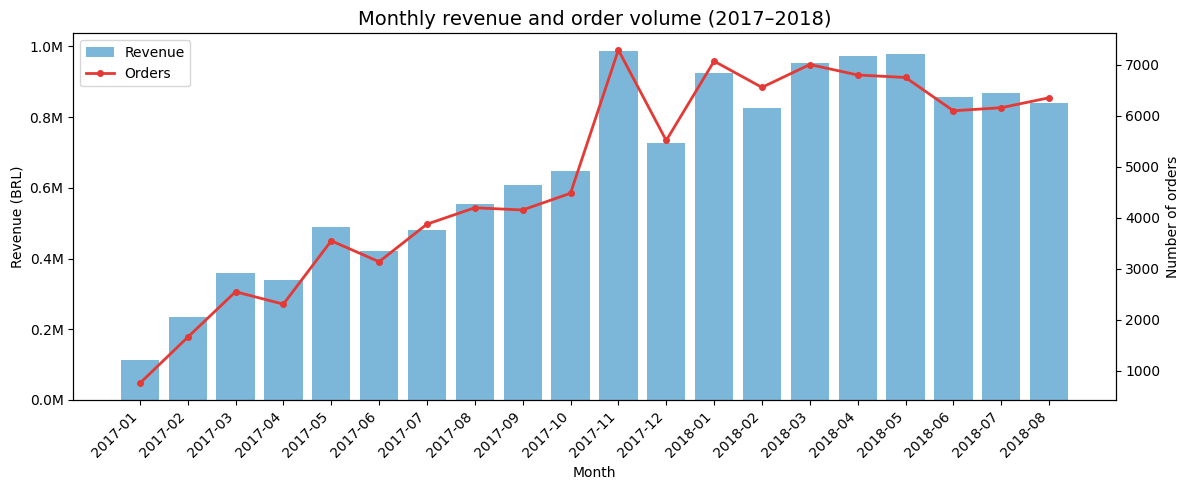

In [5]:
# Visualization dual axis: revenue + order volume
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(
    monthly_stats["purchase_year_month"],
    monthly_stats["total_revenue"],
    color="#5BA4CF",
    alpha=0.8,
    label="Revenue"
)

ax2.plot(
    monthly_stats["purchase_year_month"],
    monthly_stats["orders_count"],
    color="#E53935",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Orders"
)

ax1.set_title("Monthly revenue and order volume (2017–2018)", fontsize=14)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (BRL)")
ax2.set_ylabel("Number of orders")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.set_xticks(range(len(monthly_stats)))
ax1.set_xticklabels(monthly_stats["purchase_year_month"], rotation=45, ha="right")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("viz_1_monthly_revenue.png", dpi=150)
plt.show()

We can notice on the graph an overall growing trend and a strong positive relationship between monthly revenue and order volume, indicating that business growth was primarily driven by increasing customer activity. Both metrics move together throughout the period, suggesting the average order value remained stable over time.

From early 2017 to late 2017, the platform experienced rapid growth in both sales and customer demand.

Several important seasonal patterns can be observed:

- A major sales peak occurred in November 2017, when both revenue and order volume reached their highest levels. This spike was likely influenced by Black Friday and holiday shopping campaigns.
- A noticeable decline followed in December 2017, which may indicate post-promotion normalization after the November sales peak.
- During 2018, revenue remained relatively stable at a high level, suggesting that the platform maintained strong customer demand.

The analysis suggests that the platform experienced strong marketplace growth during the observed period. Seasonal spikes highlight the importance of promotional campaigns and operational planning during high-demand periods.

### Revenue Contribution by Product Category

This analysis examines which product categories generate the highest revenue and how sales are distributed across the platform’s product portfolio.

Understanding highest revenue category helps to identify:

- the platform’s strongest-performing product segments
- customer purchasing preferences
- dependency on specific product categories
- opportunities for marketing focus

In [6]:
# Revenue by product category
category_revenue = (
    clean_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

# Revenue share %
category_revenue["revenue_share_pct"] = (
    category_revenue["total_revenue"] / category_revenue["total_revenue"].sum() * 100
).round(2)

category_revenue.head(10)

,product_category_name_english,total_revenue,orders_count,revenue_share_pct
43,health_beauty,1229557.50,8610,9.33
71,watches_gifts,1163187.91,5489,8.83
7,bed_bath_table,1022955.77,9267,7.76
65,sports_leisure,952661.40,7512,7.23
15,computers_accessories,887944.60,6517,6.74
39,furniture_decor,706237.17,6258,5.36
49,housewares,614341.62,5734,4.66
20,cool_stuff,609158.00,3552,4.62
5,auto,577721.09,3801,4.38
42,garden_tools,469135.40,3443,3.56


In [7]:
# How many categories in total? 
print(f'Total number of product categories: {clean_df["product_category_name_english"].nunique()}')

Total number of product categories: 72


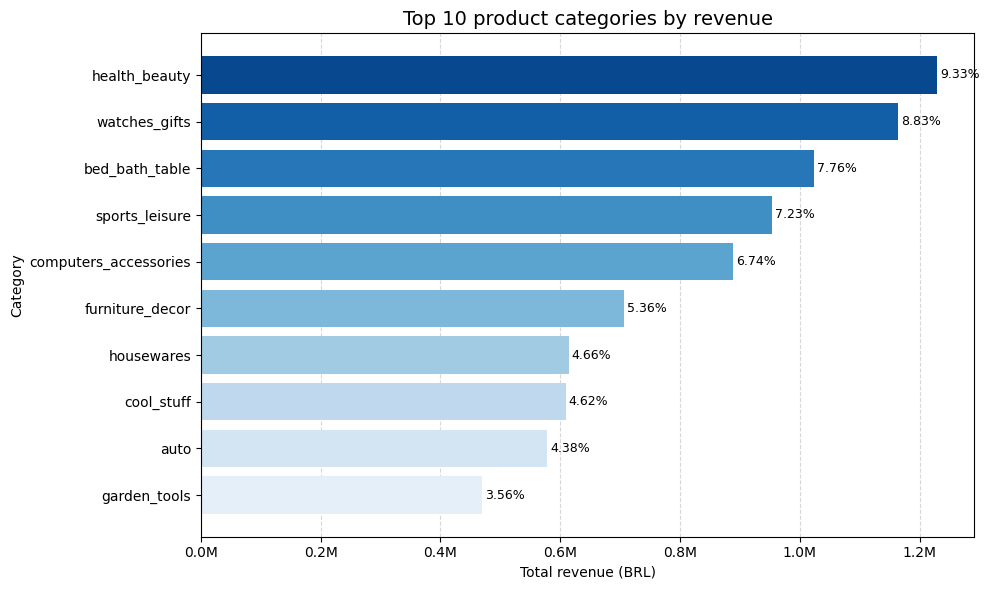

In [8]:
# Viz of top 10 product categories
fig, ax = plt.subplots(figsize=(10, 6))

top10 = category_revenue.head(10)

ax.barh(
    top10["product_category_name_english"],
    top10["total_revenue"],
    color=sns.color_palette("Blues_r", 10)
)

ax.set_title("Top 10 product categories by revenue", fontsize=14)
ax.set_xlabel("Total revenue (BRL)")
ax.set_ylabel("Category")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))


for i, (rev, pct) in enumerate(zip(top10["total_revenue"], top10["revenue_share_pct"])):
    ax.text(rev + 5000, i, f"{pct}%", va="center", fontsize=9)

ax.invert_yaxis()
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.yaxis.grid(False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("viz_2_category_revenue.png", dpi=150)
plt.show()

The highest revenue-generating category was Health & Beauty, contributing approximately 9.3% of total sales revenue, followed by:
- Watches & Gifts 
- Bed & Bath Table 
- Sports & Leisure 
- Computers & Accessories

The results suggest that customers show particularly strong demand for: personal care products, home-related items, electronics and accessories, lifestyle and leisure products.

**Key observations:**
- Revenue is spread across many categories — the top category holds less than 10% of total sales, indicating a well-diversified product portfolio
- `watches_gifts` has fewer orders than `bed_bath_table` (5,493 vs 9,272) but higher revenue, suggesting higher average order value
- Top 10 categories account for ~62% of total revenue

From a business perspective, these categories may represent the most valuable areas for:
- marketing investments,
- inventory prioritization,
- logistics optimization,
- seller partnerships.

### Revenue Contribution by State

A pivot table was created to summarize key metrics by customer state: total revenue, number of orders, unique customers, and revenue share.

This analysis examines how revenue and customer activity are distributed across Brazilian states.

The goal is to identify:

- the platform’s strongest regional markets
- geographic revenue concentration
- customer distribution patterns
- potential opportunities for regional expansion

In [9]:
# Pivot table — state performance summary
pivot_table = clean_df.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id"
).pivot_table(
    index="customer_state",
    values=["price", "order_id", "customer_unique_id"],
    aggfunc={
        "price": "sum",
        "order_id": "nunique",
        "customer_unique_id": "nunique"
    }
).round(2)

pivot_table.columns = ["unique_customers", "orders_count", "total_revenue"]
pivot_table["revenue_share_pct"] = (
    pivot_table["total_revenue"] / pivot_table["total_revenue"].sum() * 100
).round(2)

pivot_table = pivot_table.sort_values("total_revenue", ascending=False)
pivot_table.head(10)

,unique_customers,orders_count,total_revenue,revenue_share_pct
customer_state,,,,
SP,39058,40399,5054516.95,38.35
RJ,11879,12310,1751433.85,13.29
MG,10969,11319,1548206.88,11.75
RS,5150,5327,726194.92,5.51
PR,4750,4903,664048.00,5.04
SC,3441,3537,504774.07,3.83
BA,3155,3253,493339.26,3.74
DF,2013,2074,295454.64,2.24
GO,1889,1950,281932.21,2.14


The analysis shows that revenue and customer activity are heavily concentrated in a small number of Brazilian states.

São Paulo (SP) is the platform’s dominant market, contributing approximately 38% of total revenue and the largest customer base.

Rio de Janeiro (RJ) and Minas Gerais (MG) are the next strongest-performing states, together contributing a significant share of marketplace revenue and orders - 25% of total revenue. 

Southern and southeastern states generally demonstrate stronger commercial performance compared to other regions.

In most states, the number of orders slightly exceeds the number of unique customers, indicating limited repeat purchasing behavior across the platform.

The results suggest that marketplace activity is strongly concentrated in economically developed regions with larger populations and stronger purchasing power.

While the platform generates strong revenue in its main markets, it also depends heavily on a small number of regions. Expanding into less active states could help create more balanced long-term growth.

### Seller Performance and Customer Satisfaction

This analysis evaluates seller performance by comparing revenue generation, order volume, and average customer review scores.

The goal is to identify:

- top-performing sellers
- relationships between sales volume and customer satisfaction
- sellers with strong operational performance
- potential risks among high-volume but low-rated merchants

In [10]:
# Top sellers by revenue and satisfaction
seller_stats = (
    clean_df.groupby(["seller_id", "seller_state"])
    .agg(
        total_revenue=("price", "sum"),
        orders_count=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

seller_stats.head(10)

,seller_id,seller_state,total_revenue,orders_count,avg_review_score
829,4869f7a5dfa277a7dca6462dcf3b52b2,SP,226987.93,1124,4.14
975,53243585a1d6dc2643021fd1853d8905,BA,217940.44,348,4.13
853,4a3ca9315b744ce9f8e9374361493884,SP,196882.12,1772,3.83
2880,fa1c13f2614d7b5c4749cbc52fecda94,SP,190917.14,578,4.37
1472,7c67e1448b00f6e969d365cea6b010ab,SP,186570.05,973,3.35
1496,7e93a43ef30c4f03f38b393420bc753a,SP,164582.49,318,4.36
2524,da8622b14eb17ae2831f4ac5b9dab84a,SP,159816.87,1311,4.07
1442,7a67c85e85bb2ce8582c35f2203ad736,SP,139658.69,1145,4.27
186,1025f0e2d44d7041d6cf58b6550e0bfa,SP,138208.56,910,3.88
1747,955fee9216a65b617aa5c0531780ce60,SP,131836.71,1261,4.09


The highest-performing seller generated more than R$226k in revenue while maintaining a strong average review score above 4.1. Several other top sellers also combined high sales volume with consistently positive customer ratings.

At the same time, some high-revenue sellers received noticeably lower review scores, suggesting that strong sales performance does not always guarantee positive customer experience.

The platform may benefit from monitoring high-volume sellers with lower customer ratings and identifying operational best practices among top-performing sellers.

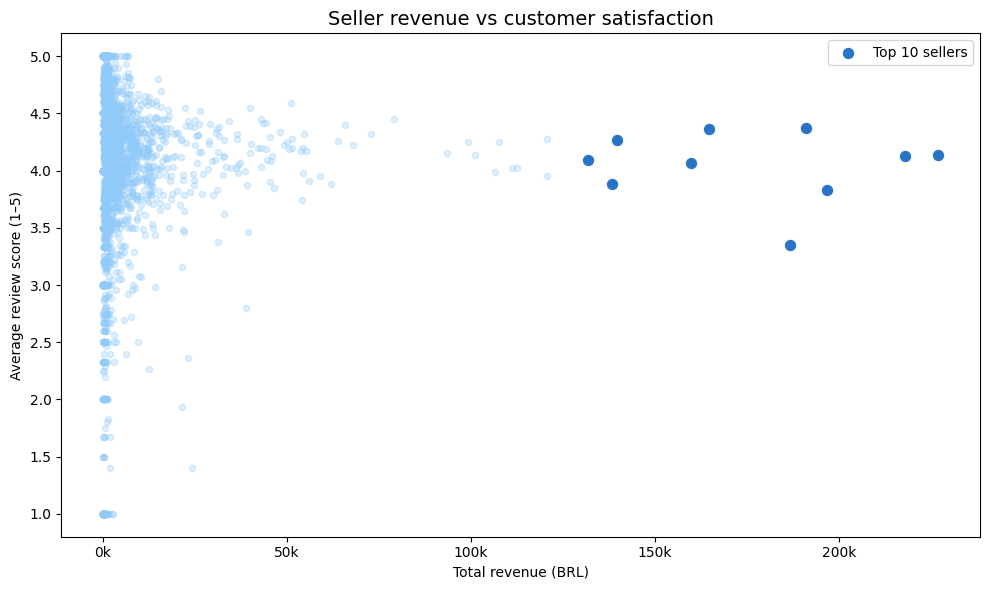

In [11]:
# Scatter plot: revenue vs review score
fig, ax = plt.subplots(figsize=(10, 6))

# All sellers as background
ax.scatter(
    seller_stats["total_revenue"],
    seller_stats["avg_review_score"],
    alpha=0.3,
    s=20,
    color="#90CAF9"
)

# Top 10 highlighted
top10_sellers = seller_stats.head(10)
ax.scatter(
    top10_sellers["total_revenue"],
    top10_sellers["avg_review_score"],
    alpha=0.9,
    s=80,
    color="#1565C0",
    edgecolors="white",
    linewidth=0.8,
    label="Top 10 sellers"
)

ax.set_title("Seller revenue vs customer satisfaction", fontsize=14)
ax.set_xlabel("Total revenue (BRL)")
ax.set_ylabel("Average review score (1–5)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_3_seller_stats.png", dpi=150)
plt.show()

The scatterplot highlights that most sellers are concentrated in the lower revenue range, while only a small number of merchants generate exceptionally high revenue. The visualization suggests that marketplace revenue is heavily concentrated among a limited group of top-performing sellers.

The relationship between revenue and customer satisfaction is mixed: some high-revenue sellers maintain strong review scores, while others receive noticeably lower ratings despite large sales volumes.

The results suggest that seller growth should be evaluated not only by revenue performance, but also by customer satisfaction and operational quality.

### Payment Method Analysis

This analysis explores customer payment preferences and compares transaction volume and average order value across different payment methods.

The goal is to understand:

- the most commonly used payment types
- differences in customer purchasing behavior
- how payment methods relate to average order value
- potential opportunities to improve checkout experience and payment flexibility

In [12]:
# Payment methods analysis
payment_stats = (
    payments.groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        avg_order_value=("payment_value", "mean"),
        total_value=("payment_value", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("transactions", ascending=False)
)

payment_stats["transactions_pct"] = (
    payment_stats["transactions"] / payment_stats["transactions"].sum() * 100
).round(2)

payment_stats

,payment_type,transactions,avg_order_value,total_value,transactions_pct
1,credit_card,76795,163.32,12542084.19,73.92
0,boleto,19784,145.03,2869361.27,19.04
4,voucher,5775,65.70,379436.87,5.56
2,debit_card,1529,142.57,217989.79,1.47
3,not_defined,3,0.00,0.00,0.00


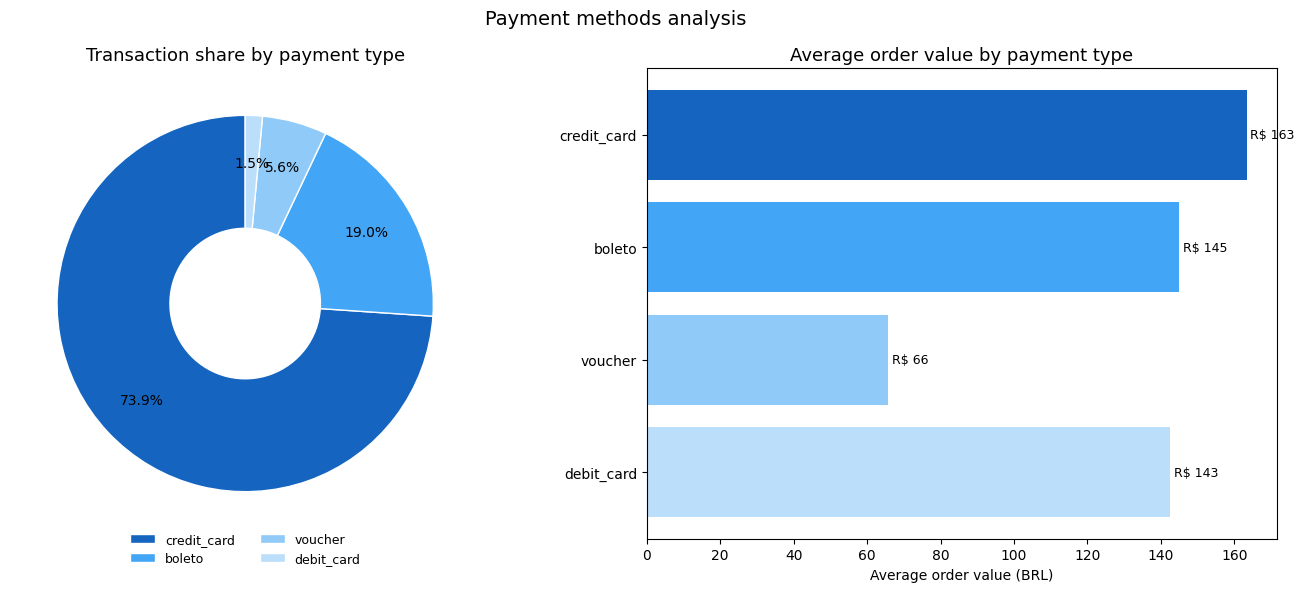

In [13]:
# Removing not_defined 3 transactions with zero value
payment_clean = payment_stats[payment_stats["payment_type"] != "not_defined"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#1565C0", "#42A5F5", "#90CAF9", "#BBDEFB"]

# Donut chart: transaction share
sizes = payment_clean["transactions_pct"]
labels = payment_clean["payment_type"]

wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels=None, 
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1, "width": 0.6},
    pctdistance=0.75 
)
for at in autotexts:
    at.set_fontsize(10)

axes[0].legend(
    wedges, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=9,
    frameon=False
)
axes[0].set_title("Transaction share by payment type", fontsize=13)

# Horizontal bar: avg order value
axes[1].barh(payment_clean["payment_type"], payment_clean["avg_order_value"], color=colors)
axes[1].set_title("Average order value by payment type", fontsize=13)
axes[1].set_xlabel("Average order value (BRL)")
axes[1].invert_yaxis()
axes[1].grid(False)
for i, v in enumerate(payment_clean["avg_order_value"]):
    axes[1].text(v + 1, i, f"R$ {v:.0f}", va="center", fontsize=9)

plt.suptitle("Payment methods analysis", fontsize=14)
plt.tight_layout()
plt.savefig("viz_4_payment_methods.png", dpi=150, bbox_inches="tight")
plt.show()

Credit cards are the dominant payment method on the platform, accounting for nearly 74% of all transactions.

Boleto was the second most popular payment method, representing approximately 19% of purchases, while voucher and debit card payments have relatively small shares of total transactions.

Payment methods also differ in average order value:
  - credit card purchases show the highest average order value,
  - boleto and debit card transactions remain relatively high,
  - voucher payments have substantially lower average purchase amounts.

The results suggest that customers using credit cards tend to place larger purchases compared to customers using other payment methods.

The strong dominance of credit card transactions suggests that payment flexibility likely plays an important role in customer purchasing behavior.

The platform may benefit from optimizing the credit card checkout experience and supporting installment payment options to improve conversion and transaction value.

<a id="customer-experience-and-logistics-performance"></a>
## Customer Experience and Logistics Performance

This section analyzes operational performance and customer satisfaction, focusing on delivery efficiency, review scores, regional logistics differences, and factors contributing to customer dissatisfaction.

<a id="impact-of-delivery-delays-on-customer-satisfaction"></a>
### Impact of Delivery Delays on Customer Satisfaction

This analysis examines how delivery performance affects customer review scores.

The goal is to evaluate whether late deliveries lead to lower customer satisfaction and to better understand the operational impact of logistics performance on the overall marketplace experience.

In [14]:
# Delivery delay vs review score
delay_vs_review = (
    clean_df[["delivery_delay_days", "review_score", "is_late"]]
    .dropna()
)

# Average review score: late vs on time
delay_summary = (
    delay_vs_review.groupby("is_late")["review_score"]
    .agg(["mean", "median", "count"])
    .round(2)
)
delay_summary.index = ["On time", "Late"]
delay_summary

,mean,median,count
On time,4.21,5.0,101971
Late,2.26,1.0,7078


A strong relationship exists between delivery performance and customer satisfaction.

Orders delivered on time received an average review score of 4.21, while late deliveries received a much lower average score of 2.26.

Median review scores highlight this difference even more clearly:
  - on-time deliveries most commonly received the maximum rating of 5 stars,
  - late deliveries most frequently received ratings close to 1 star.

The results show that delivery performance is one of the most important operational factors affecting customer satisfaction and marketplace reputation.

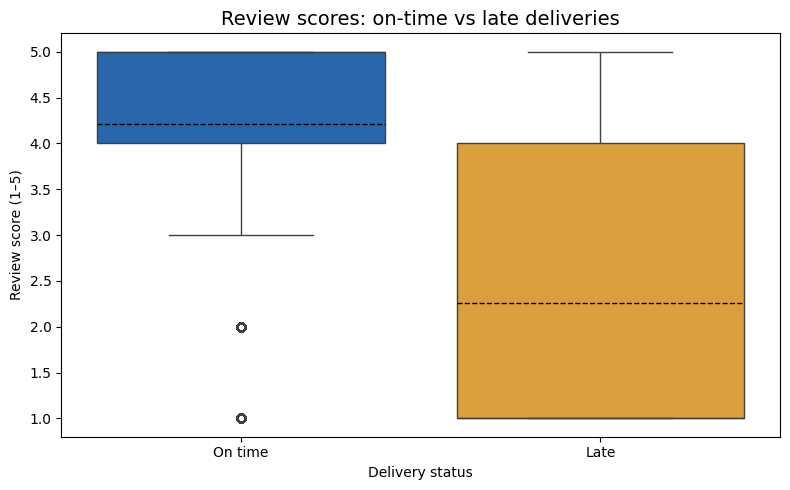

In [15]:
# Box-plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=delay_vs_review,
    x="is_late",
    y="review_score",
    hue="is_late",
    palette={False: "#1565C0", True: "#F5A623"},
    legend=False,
    showmeans=True,
    meanprops={
        "linestyle": "--",
        "linewidth": 1,
        "color": "black"
    },
    meanline=True,
    ax=ax
)

ax.set_title("Review scores: on-time vs late deliveries", fontsize=14)
ax.set_xlabel("Delivery status")
ax.set_ylabel("Review score (1–5)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["On time", "Late"])
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_5_review_vs_delay.png", dpi=150)
plt.show()

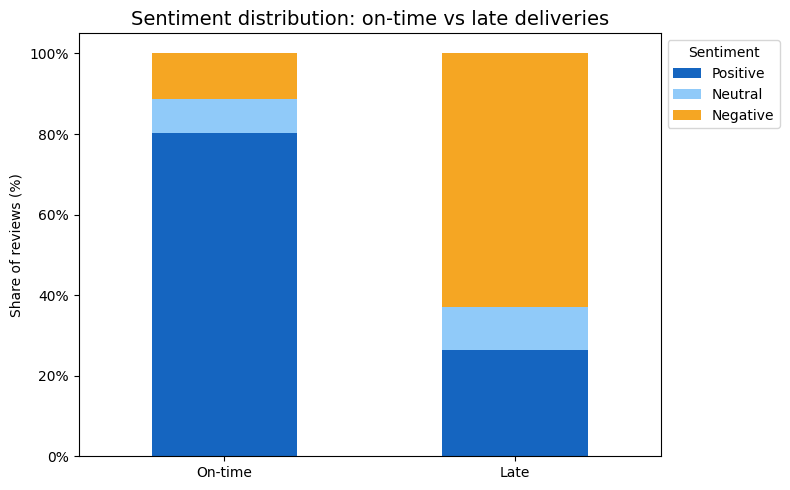

In [16]:
# Sentiment distribution by delivery status
sentiment_delivery = (
    clean_df.groupby(["is_late", "review_sentiment_group"])
    .size()
    .reset_index(name="count")
)
sentiment_delivery["pct"] = (
    sentiment_delivery.groupby("is_late")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

pivot = sentiment_delivery.pivot(
    index="is_late", columns="review_sentiment_group", values="pct"
)[["Positive", "Neutral", "Negative"]]

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#1565C0", "#90CAF9", "#F5A623"],
    width=0.5
)
ax.set_title("Sentiment distribution: on-time vs late deliveries", fontsize=14)
ax.set_xlabel("")
ax.set_xticklabels(["On-time", "Late"], rotation=0)
ax.set_ylabel("Share of reviews (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Sentiment", bbox_to_anchor=(1, 1))
ax.grid(False)
plt.tight_layout()
plt.savefig("viz_6_sentiment_delivery.png", dpi=150)
plt.show()

Orders delivered on time show consistently high review scores, with most ratings concentrated between 4 and 5 stars.

Late deliveries demonstrate significantly lower review scores and much greater variability in customer feedback.

The median review score for delayed orders is close to 1 star, indicating a strong negative customer reaction to delivery issues.

The visualization confirms that logistics performance is a critical driver of customer satisfaction and overall customer experience.

<a id="hypothesis-test-late-deliveries"></a>
### Hypothesis Test: Late Deliveries and Review Scores 

A statistical hypothesis test was performed to determine whether late deliveries lead to lower customer review scores.

H₀: there is no significant difference in review scores between on-time and late deliveries.

H₁: late deliveries have significantly lower review scores.


In [17]:
# Preparing samples
on_time_scores = clean_df[clean_df["is_late"] == False]["review_score"].dropna()
late_scores    = clean_df[clean_df["is_late"] == True]["review_score"].dropna()

# Performing t-test
t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores, equal_var=False)

print(f"On time — mean score: {on_time_scores.mean():.2f}, n = {len(on_time_scores):,}")
print(f"Late    — mean score: {late_scores.mean():.2f}, n = {len(late_scores):,}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.10f}")

if p_value < 0.05:
    print("\nReject H0: late deliveries significantly lower review scores.")
else:
    print("\nFail to reject H0.")

On time — mean score: 4.21, n = 101,971
Late    — mean score: 2.26, n = 7,078
t-statistic: 102.305
p-value:     0.0000000000

Reject H0: late deliveries significantly lower review scores.


A two-sample t-test was used to compare review scores between on-time and late deliveries.

The average review score for on-time deliveries was 4.21, while late deliveries received an average score of 2.26.

Since the p-value is significantly below 0.05, the null hypothesis was rejected.

The results confirm that late deliveries are associated with significantly lower customer review scores.

<a id="delivery-performance-and-customer-satisfaction-by-state"></a>
### Delivery Performance and Customer Satisfaction by State

This analysis explores how delivery performance varies across Brazilian states and whether longer delivery times are associated with lower customer review scores.

The goal is to identify regional logistics patterns and evaluate how operational efficiency impacts customer satisfaction.

In [18]:
# Average delivery time and review score by state
state_stats = (
    clean_df.groupby("customer_state")
    .agg(
        avg_delivery_days=("delivery_delay_days", "mean"),
        avg_review_score=("review_score", "mean"),
        orders_count=("order_id", "nunique")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_delivery_days", ascending=False)
)

state_stats.head(10)

,customer_state,avg_delivery_days,avg_review_score,orders_count
21,RR,28.27,3.89,40
3,AP,27.75,4.26,67
2,AM,25.96,4.11,145
1,AL,23.97,3.83,396
13,PA,23.27,3.84,942
9,MA,21.17,3.75,713
24,SE,20.91,3.89,332
5,CE,20.51,3.87,1273
0,AC,20.33,4.13,80
14,PB,20.09,4.04,516


Pearson correlation: -0.314


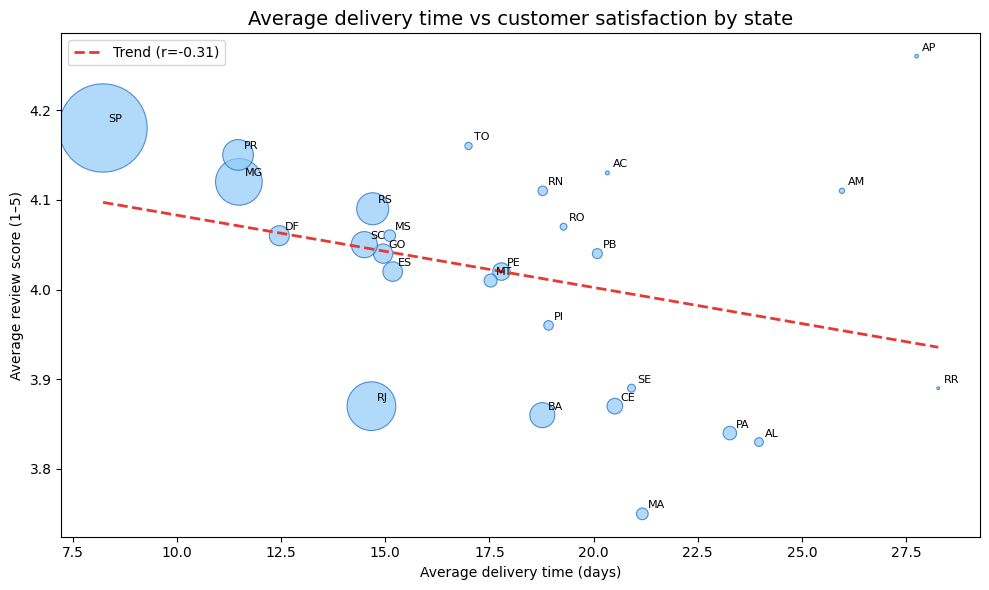

In [19]:
# Correlation between delivery time and review score
correlation = state_stats["avg_delivery_days"].corr(state_stats["avg_review_score"])
print(f"Pearson correlation: {correlation:.3f}")

# Scatter plot: delivery days vs review score
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    state_stats["avg_delivery_days"],
    state_stats["avg_review_score"],
    s=state_stats["orders_count"] / 10,
    alpha=0.7,
    color="#90CAF9",
    edgecolors="#1565C0",
    linewidth=0.8
)

# State labels
for _, row in state_stats.iterrows():
    ax.annotate(
        row["customer_state"],
        (row["avg_delivery_days"], row["avg_review_score"]),
        fontsize=8,
        ha="left",
        xytext=(4, 4),
        textcoords="offset points"
    )

# Trend line
m, b = np.polyfit(state_stats["avg_delivery_days"], state_stats["avg_review_score"], 1)
x_range = np.linspace(state_stats["avg_delivery_days"].min(), 
                       state_stats["avg_delivery_days"].max(), 100)
ax.plot(x_range, m * x_range + b, color="#E53935", linewidth=2, 
        linestyle="--", label=f"Trend (r={correlation:.2f})")

ax.set_title("Average delivery time vs customer satisfaction by state", fontsize=14)
ax.set_xlabel("Average delivery time (days)")
ax.set_ylabel("Average review score (1–5)")
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.savefig("viz_7_state_delivery_satisfaction.png", dpi=150)
plt.show()

A moderate negative correlation exists between average delivery time and customer satisfaction across Brazilian states (Pearson correlation = -0.31).

In general, states with longer delivery times tend to receive lower average review scores, suggesting that slower logistics negatively affect customer experience.

However, the correlation is not very strong, indicating that delivery time is only one of several factors influencing customer satisfaction.

- São Paulo (SP), which generated the highest order volume, demonstrated one of the shortest delivery times while maintaining high customer review scores. This may reflect stronger logistics infrastructure and operational efficiency.

- Several geographically remote states, including RR, AP, and AM, experienced the longest average delivery times.

- States such as Maranhão (MA), Alagoas (AL), and Pará (PA) combined relatively long delivery times with lower customer review scores, indicating potential areas for logistics improvement.


The results reinforce the importance of logistics performance as a key driver of customer satisfaction and operational success. Improving delivery efficiency in remote and underperforming regions may help increase customer satisfaction and strengthen marketplace performance across different states.

<a id="low-rated-product-categories-and-customer-dissatisfaction"></a>
### Low-Rated Product Categories and Customer Dissatisfaction

This analysis identifies product categories with the lowest customer review scores and explores possible operational factors contributing to customer dissatisfaction.

The analysis considers:
- average review scores,
- delivery performance,
- late delivery rates,
- and category-specific operational characteristics.

In [20]:
# Categories with lowest review scores
category_reviews = (
    clean_df.groupby("product_category_name_english")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count"),
        avg_delivery_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
    .round(2)
    .reset_index()
)

# Min 100 reviews for statistical reliability
category_reviews = category_reviews[category_reviews["total_reviews"] >= 100]

category_reviews_sorted = category_reviews.sort_values("avg_review_score")
category_reviews_sorted.head(10)

,product_category_name_english,avg_review_score,total_reviews,avg_delivery_days,late_rate
57,office_furniture,3.52,1649,20.32,0.08
34,fixed_telephony,3.75,247,12.07,0.04
30,fashion_male_clothing,3.78,123,12.36,0.06
4,audio,3.83,356,12.90,0.12
47,home_confort,3.86,427,13.04,0.09
70,unknown,3.93,1545,12.25,0.07
40,furniture_living_room,3.93,490,13.29,0.07
7,bed_bath_table,3.93,10823,12.33,0.07
48,home_construction,3.96,592,12.76,0.06
39,furniture_decor,3.96,8016,12.37,0.07


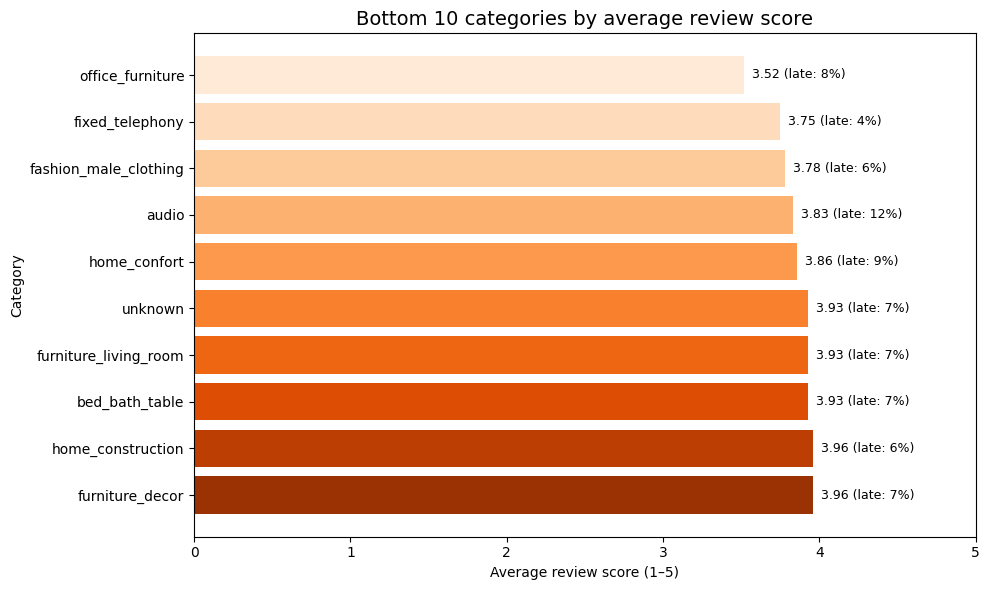

In [21]:
# Bottom 10 categories by review score
bottom10 = category_reviews_sorted.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    bottom10["product_category_name_english"],
    bottom10["avg_review_score"],
    color=sns.color_palette("Oranges", 10)
)

ax.set_title("Bottom 10 categories by average review score", fontsize=14)
ax.set_xlabel("Average review score (1–5)")
ax.set_ylabel("Category")
ax.set_xlim(0, 5)
ax.invert_yaxis()
ax.grid(False)

# Add score labels
for i, (score, late) in enumerate(zip(bottom10["avg_review_score"],
                                       bottom10["late_rate"])):
    ax.text(score + 0.05, i, f"{score} (late: {late*100:.0f}%)",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("viz_8_category_reviews.png", dpi=150)
plt.show()

Office Furniture received the lowest average review score (3.52) among categories with sufficient review volume. This category also showed one of the longest average delivery times (over 20 days), suggesting that logistics challenges may strongly contribute to customer dissatisfaction.

Other relatively low-rated categories included:
  - Fixed Telephony,
  - Fashion Male Clothing,
  - Audio,
  - Home Comfort,
  - and several furniture-related categories.

Furniture categories generally combined longer delivery times with lower review scores, indicating that shipping complexity and delivery performance may negatively affect customer experience.

For electronics and clothing categories, dissatisfaction may also be influenced by product quality, unmet expectations, or product fit issues rather than delivery performance alone.

The results suggest several opportunities to improve customer satisfaction:

- optimize shipping and delivery processes,
- improve packaging quality for large or fragile products,
- strengthen seller quality control,
- and provide clearer delivery communication and customer support.

# Conclusions and Business Recommendations

## Revenue and Sales Performance

### Key Insights

- The platform showed strong revenue and order growth throughout 2017, with a major peak in November 2017 driven by Black Friday demand.
- By 2018, monthly revenue stabilized at approximately R$800K–980K, suggesting the business entered a more mature growth stage.
- Revenue and order volume moved closely together over time, indicating relatively stable average order values.
- The top 26% of total revenue was generated by the below categories:
  - `health_beauty`,
  - `watches_gifts`,
  - `bed_bath_table`,

- Revenue was heavily concentrated geographically:
  - São Paulo (SP) alone generated approximately 38% of total revenue,
  - the top 3 states (SP, RJ, MG) accounted for nearly 63%.
- Marketplace sales were also concentrated among a relatively small group of top-performing sellers.
- Credit cards dominated payment behavior, representing around 74% of all transactions and the highest average order value among payment methods.

### Business Recommendations

1. **Reduce geographic concentration risk**  
   Expanding marketing efforts in underrepresented states may diversify revenue sources and reduce dependence on a few core regions.

2. **Strengthen relationships with top-performing sellers**  
   Supporting high-performing merchants with operational tools and promotional opportunities may help sustain marketplace growth.

3. **Prepare strategically for seasonal demand peaks**  
   Black Friday and other high-demand periods require proactive inventory planning, logistics preparation, and seller coordination.

4. **Optimize the credit card checkout experience**  
   Since credit cards dominate transactions and generate the highest order values, improving payment flexibility and installment options could further increase conversion rates.


---

## Customer Experience and Logistics Performance

### Key Insights

- Delivery performance had a major impact on customer satisfaction.
- On-time deliveries achieved an average review score of 4.21, while late deliveries averaged only 2.26.
- Statistical testing confirmed that the difference in review scores between on-time and late deliveries was highly significant (p < 0.05).
- States with longer average delivery times generally showed lower customer satisfaction scores.
- Northern states such as RR, AP, and AM experienced the slowest delivery times.
- São Paulo combined short delivery times with high customer satisfaction, indicating stronger logistics efficiency.
- Product categories with the lowest ratings — especially `office_furniture` — were often associated with longer delivery times and elevated late-delivery rates.
- Large or fragile categories such as furniture appeared more sensitive to logistics and shipping quality issues.

### Business Recommendations

1. **Improve logistics performance in remote regions**  
   Partnering with regional logistics providers may reduce delivery delays and improve customer satisfaction in northern states.

2. **Prioritize late-delivery reduction initiatives**  
   Since delivery delays strongly impact customer reviews, improving shipping reliability should be treated as a core operational priority.

3. **Monitor low-rated high-volume sellers**  
   Sellers generating strong sales but poor customer ratings should be flagged for operational review and quality control.

4. **Improve shipping processes for furniture-related categories**  
   Better packaging, delivery coordination, and supplier management may help reduce dissatisfaction in bulky-product categories.

5. **Enhance customer communication during delivery**  
   More transparent tracking updates and delivery notifications could help reduce customer frustration during delays.